# 1. Introduction

**Notebook:** `02_eda.ipynb`

**Mục tiêu:** Thực hiện phân tích thống kê chuỗi thời gian nâng cao trên bộ dữ liệu nhu cầu điện năng của lưới điện Great Britain (GB) đã làm sạch (`electricity_cleaned.csv`). Notebook này tập trung xây dựng nền tảng toán học gồm tính dừng, tự tương quan, phân rã tín hiệu và tương quan chéo đa biến, nhằm định hướng cho bước xây dựng đặc trưng và mô hình hóa ở notebook tiếp theo, đúng với chuỗi logic đã trình bày trong đề xuất nghiên cứu cập nhật *"Dự Báo Nhu Cầu Điện Năng Great Britain Theo Chu Kỳ Quyết Toán Bằng Học Máy Dựa Trên Đặc Trưng Thời Gian Tuần Hoàn"*, phiên bản so sánh sáu mô hình: hai đường cơ sở mùa vụ ngây thơ **SNaive Daily** ($\hat{Y}_t = Y_{t-48}$) và **SNaive Weekly** ($\hat{Y}_t = Y_{t-336}$), cùng với Linear Regression, Random Forest, XGBoost và LightGBM.

**Chuỗi phân tích:**

**B1:** Data Ingestion and Indexing, nạp dữ liệu sạch và dựng trục thời gian liên tục 30 phút.

**B2:** Stationarity Testing, kiểm định tính dừng bằng kiểm định Augmented Dickey Fuller.

**B3:** Autocorrelation Analysis, khảo sát hàm tự tương quan ACF và tự tương quan riêng phần PACF nhằm định lượng chính xác độ trễ 48 (ngày) và độ trễ 336 (tuần), hai mốc thời gian sẽ trở thành công thức của hai đường cơ sở SNaive Daily và SNaive Weekly ở notebook huấn luyện mô hình.

**B4:** Time Series Signal Decomposition, phân rã tín hiệu nhu cầu điện thành thành phần xu hướng, mùa vụ và phần dư bằng phương pháp STL đa mùa vụ.

**B5:** Multivariate Correlation Mapping, phân tích tương tác giữa nhu cầu điện và sản lượng năng lượng tái tạo nhúng.


## Mô tả bộ dữ liệu (Dataset Description)

Notebook này tiếp tục làm việc trên **Historic Demand Data**, bộ dữ liệu do **NESO (National Energy System Operator)** công bố công khai, đã được làm sạch ở `01_pre_eda_and_cleaning.ipynb`.

**Phạm vi địa lý Great Britain (GB), không phải toàn bộ United Kingdom (UK), và không chỉ England:** các cột nhu cầu điện (`ND`, `TSD`, `ENGLAND_WALES_DEMAND`) đại diện cho phụ tải hợp nhất của ba vùng cấu thành Great Britain - England, Wales và Scotland. Bộ dữ liệu **không bao gồm Northern Ireland**, vì lưới điện Northern Ireland vận hành trong **Single Electricity Market (SEM)** cùng với Cộng hòa Ireland, dưới một cơ quan điều tiết khác, nằm ngoài phạm vi vận hành của NESO. Mọi phát hiện thống kê trong notebook này (tính dừng, tự tương quan, phân rã mùa vụ, tương quan đa biến) vì vậy chỉ có giá trị đại diện cho GB, không nên khái quát hoá thành kết luận cho "Vương quốc Anh" hay "UK" trong phần Discussion của bài báo.

**Đơn vị vận hành NESO:** NESO là đơn vị vận hành hệ thống quốc gia cho Great Britain, chính thức hoạt động từ 1 tháng 10 năm 2024, kế thừa **National Grid ESO** sau khi được nhà nước Anh mua lại theo Energy Act 2023. Các cột đo lường năng lượng tái tạo nhúng (`EMBEDDED_WIND_GENERATION`, `EMBEDDED_SOLAR_GENERATION`) và các cột dòng liên kết (`IFA_FLOW`, `IFA2_FLOW`, `BRITNED_FLOW`, `MOYLE_FLOW`, ...) được phân tích tương quan ở Phần 4.4 cũng nằm trong cùng phạm vi công bố này.


### Thiết lập môi trường

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import MSTL

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme(style="white")

plt.rcParams.update({
    "figure.dpi": 100,
    "savefig.dpi": 600,
    "savefig.bbox": "tight",
    "font.size": 13,
    "axes.labelsize": 14,
    "axes.titlesize": 13,
    "axes.titleweight": "normal",
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "figure.figsize": (14, 5),
})

# Số chu kỳ quyết toán 30 phút trong một ngày và trong một tuần, dùng xuyên suốt notebook
CHU_KY_MOT_NGAY = 48
CHU_KY_MOT_TUAN = 48 * 7
import os

FIGURES_DIR = "figures"
os.makedirs(FIGURES_DIR, exist_ok=True)


def save_figure(fig, name, also_pdf=False):
    """Lưu hình ở định dạng PNG chất lượng cao (dpi=600) với tên có đánh số thứ tự,
    phục vụ nhúng trực tiếp vào bài báo và tra cứu lại khi cần.
    SUA (uu tien 3, docx #3): also_pdf=True them ban PDF vector cho cac hinh ve
    duong (ACF/PACF/MSTL) -- Springer yeu cau 600dpi cho loai hinh nay, PDF vector
    thoa man khong can chon dpi va khong bi mo khi thu nho trong LaTeX."""
    path = os.path.join(FIGURES_DIR, f"{name}.png")
    fig.savefig(path, format="png", dpi=600, bbox_inches="tight")
    print(f"Đã lưu hình: {path}")
    if also_pdf:
        pdf_path = os.path.join(FIGURES_DIR, f"{name}.pdf")
        fig.savefig(pdf_path, format="pdf", bbox_inches="tight")
        print(f"Đã lưu hình (vector, dùng trong paper): {pdf_path}")


# 2. Data Overview

### 1.1 Nạp dữ liệu sạch

In [ ]:
df_raw = pd.read_csv("electricity_cleaned.csv")
df_raw["SETTLEMENT_DATE"] = pd.to_datetime(df_raw["SETTLEMENT_DATE"])
df_raw = df_raw.sort_values(["SETTLEMENT_DATE", "SETTLEMENT_PERIOD"]).reset_index(drop=True)

print(f"Số dòng: {df_raw.shape[0]:,} | Số cột: {df_raw.shape[1]}")
print(f"Giai đoạn: {df_raw['SETTLEMENT_DATE'].min().date()} đến {df_raw['SETTLEMENT_DATE'].max().date()}")
df_raw.head()

Số dòng: 105,216 | Số cột: 22
Giai đoạn: 2020-01-01 đến 2025-12-31


,SETTLEMENT_PERIOD,ND,TSD,ENGLAND_WALES_DEMAND,EMBEDDED_WIND_GENERATION,EMBEDDED_WIND_CAPACITY,EMBEDDED_SOLAR_GENERATION,EMBEDDED_SOLAR_CAPACITY,NON_BM_STOR,PUMP_STORAGE_PUMPING,IFA_FLOW,IFA2_FLOW,BRITNED_FLOW,MOYLE_FLOW,EAST_WEST_FLOW,NEMO_FLOW,NSL_FLOW,ELECLINK_FLOW,VIKING_FLOW,GREENLINK_FLOW,SETTLEMENT_DATE,SOURCE_FILE_YEAR
0,1,"26,340.0000","27,153.0000","23,821.0000","1,073.0000","6,465.0000",0.0000,"13,040.0000",0.0000,15.0000,"1,703.0000",0.0000,852.0000,-151.0000,-47.0000,854.0000,0.0000,0.0000,0.0000,0.0000,2020-01-01,2020
1,2,"26,921.0000","27,684.0000","24,393.0000","1,020.0000","6,465.0000",0.0000,"13,040.0000",0.0000,17.0000,"1,703.0000",0.0000,853.0000,-146.0000,0.0000,854.0000,0.0000,0.0000,0.0000,0.0000,2020-01-01,2020
2,3,"26,569.0000","27,240.0000","24,085.0000","1,010.0000","6,465.0000",0.0000,"13,040.0000",0.0000,18.0000,"1,703.0000",0.0000,852.0000,-53.0000,0.0000,854.0000,0.0000,0.0000,0.0000,0.0000,2020-01-01,2020
3,4,"25,754.0000","26,435.0000","23,350.0000","1,043.0000","6,465.0000",0.0000,"13,040.0000",0.0000,15.0000,"1,703.0000",0.0000,852.0000,-66.0000,0.0000,854.0000,0.0000,0.0000,0.0000,0.0000,2020-01-01,2020
4,5,"25,075.0000","25,824.0000","22,788.0000","1,001.0000","6,465.0000",0.0000,"13,040.0000",0.0000,15.0000,"1,704.0000",0.0000,853.0000,-74.0000,-60.0000,854.0000,0.0000,0.0000,0.0000,0.0000,2020-01-01,2020


### 2.2 Kích thước, kiểu dữ liệu và thống kê mô tả

Bước này chỉ nhắc lại tóm tắt ở mức tối thiểu; khảo sát chi tiết từng cột đã được thực hiện đầy đủ ở `01_pre_eda_and_cleaning.ipynb` (Part 2). Mục tiêu ở đây là xác nhận notebook này đang thao tác đúng trên dữ liệu đã làm sạch, trước khi dựng trục thời gian liên tục cho các phép toán chuỗi thời gian.

In [ ]:
# Tổng quan nhanh về kích thước, kiểu dữ liệu và thống kê mô tả của dữ liệu đã làm sạch
print("=== KÍCH THƯỚC VÀ KIỂU DỮ LIỆU ===\n")
print(f"Số dòng: {df_raw.shape[0]:,} | Số cột: {df_raw.shape[1]}")
print(df_raw.dtypes)

print("\n=== THỐNG KÊ MÔ TẢ (CÁC CỘT SỐ) ===\n")
cot_so = df_raw.select_dtypes(include=[float, int]).columns.tolist()
df_raw[cot_so].describe().T


=== KÍCH THƯỚC VÀ KIỂU DỮ LIỆU ===

Số dòng: 105,216 | Số cột: 22
SETTLEMENT_PERIOD                     int64
ND                                  float64
TSD                                 float64
ENGLAND_WALES_DEMAND                float64
EMBEDDED_WIND_GENERATION            float64
EMBEDDED_WIND_CAPACITY              float64
EMBEDDED_SOLAR_GENERATION           float64
EMBEDDED_SOLAR_CAPACITY             float64
NON_BM_STOR                         float64
PUMP_STORAGE_PUMPING                float64
IFA_FLOW                            float64
IFA2_FLOW                           float64
BRITNED_FLOW                        float64
MOYLE_FLOW                          float64
EAST_WEST_FLOW                      float64
NEMO_FLOW                           float64
NSL_FLOW                            float64
ELECLINK_FLOW                       float64
VIKING_FLOW                         float64
GREENLINK_FLOW                      float64
SETTLEMENT_DATE              datetime64[ns]
SOURCE_FIL

,count,mean,std,min,25%,50%,75%,max
SETTLEMENT_PERIOD,"105,216.0000",24.5000,13.8535,1.0000,12.7500,24.5000,36.2500,48.0000
ND,"105,216.0000","26,770.0046","6,217.9502","12,803.0000","21,898.0000","25,882.0000","30,709.2500","46,433.0000"
TSD,"105,216.0000","28,737.4680","5,932.9829","15,297.0000","24,227.7500","27,808.0000","32,383.0000","47,760.0000"
ENGLAND_WALES_DEMAND,"105,216.0000","24,532.1825","5,692.4958","12,040.0000","20,065.0000","23,683.0000","28,164.0000","42,458.0000"
EMBEDDED_WIND_GENERATION,"105,216.0000","1,887.1583","1,213.0450",125.0000,912.0000,"1,557.0000","2,625.0000","5,962.0000"
EMBEDDED_WIND_CAPACITY,"105,216.0000","6,549.7626",38.6420,"6,465.0000","6,527.0000","6,545.0000","6,562.0000","6,622.0000"
EMBEDDED_SOLAR_GENERATION,"105,216.0000","1,579.2563","2,484.7758",0.0000,0.0000,5.0000,"2,527.0000","14,046.0000"
EMBEDDED_SOLAR_CAPACITY,"105,216.0000","15,980.4552","2,684.8591","13,040.0000","13,724.0000","15,037.0000","17,812.0000","22,126.0000"
NON_BM_STOR,"105,216.0000",0.4184,9.9657,0.0000,0.0000,0.0000,0.0000,481.0000
PUMP_STORAGE_PUMPING,"105,216.0000",192.7583,362.2962,0.0000,7.0000,11.0000,158.0000,"1,869.0000"


### 1.2 Xây dựng trục thời gian liên tục

Mỗi chu kỳ quyết toán kéo dài 30 phút, được đánh số từ 1 đến 48 trong một ngày. Mốc thời gian cụ thể của từng quan trắc được suy ra bằng cách cộng thêm vào ngày quyết toán số phút tương ứng với vị trí chu kỳ, sau đó được thiết lập làm chỉ mục DatetimeIndex với tần suất cố định 30 phút, phục vụ trực tiếp cho các phép toán chuỗi thời gian ở các bước tiếp theo như kiểm định tính dừng, tính tự tương quan và phân rã tín hiệu.

In [ ]:
df = df_raw.copy()
df["DATETIME"] = df["SETTLEMENT_DATE"] + pd.to_timedelta((df["SETTLEMENT_PERIOD"] - 1) * 30, unit="m")
df = df.set_index("DATETIME").sort_index()

# Ép tần suất 30 phút cố định; nếu tồn tại khoảng trống trên trục thời gian, asfreq sẽ tạo dòng NaN tương ứng
df = df.asfreq("30min")

so_dong_trong = df["ND"].isna().sum()
print(f"Tần suất chỉ mục: {df.index.freq}")
print(f"Số dòng sau khi ép trục thời gian liên tục: {df.shape[0]:,}")
print(f"Số dòng trống phát sinh do thiếu mốc thời gian: {so_dong_trong}")
df[["SETTLEMENT_PERIOD", "ND", "TSD", "ENGLAND_WALES_DEMAND"]].head()

Tần suất chỉ mục: <30 * Minutes>
Số dòng sau khi ép trục thời gian liên tục: 105,216
Số dòng trống phát sinh do thiếu mốc thời gian: 0


,SETTLEMENT_PERIOD,ND,TSD,ENGLAND_WALES_DEMAND
DATETIME,,,,
2020-01-01 00:00:00,1,"26,340.0000","27,153.0000","23,821.0000"
2020-01-01 00:30:00,2,"26,921.0000","27,684.0000","24,393.0000"
2020-01-01 01:00:00,3,"26,569.0000","27,240.0000","24,085.0000"
2020-01-01 01:30:00,4,"25,754.0000","26,435.0000","23,350.0000"
2020-01-01 02:00:00,5,"25,075.0000","25,824.0000","22,788.0000"


# 3. Data Cleaning (kiểm tra bổ sung)

Dữ liệu đầu vào của notebook này đã qua toàn bộ pipeline làm sạch ở `01_pre_eda_and_cleaning.ipynb` (đồng bộ hóa DST, loại cột không nhất quán, nội suy giá trị khuyết và bất thường vật lý). Bước ép trục thời gian về tần suất 30 phút cố định ở trên (`asfreq("30min")`) là phép biến đổi có khả năng phát sinh dòng trống mới nếu tồn tại khoảng hở trên trục thời gian, nên cần được kiểm tra riêng ở đây bằng một phân tích giá trị khuyết tường minh, thay vì ngầm giả định dữ liệu vẫn liên tục tuyệt đối.

In [ ]:
# Phân tích giá trị khuyết phát sinh sau khi ép trục thời gian, và kiểm tra trùng lặp chỉ mục
bao_cao_khuyet = pd.DataFrame({
    "số dòng khuyết": df.isna().sum(),
    "tỷ lệ phần trăm khuyết (%)": (df.isna().mean() * 100).round(4),
})
bao_cao_khuyet = bao_cao_khuyet[bao_cao_khuyet["số dòng khuyết"] > 0]

so_dong_trung_lap_chi_muc = df.index.duplicated().sum()

print("=== PHÂN TÍCH GIÁ TRỊ KHUYẾT SAU KHI ÉP TRỤC THỜI GIAN ===\n")
if bao_cao_khuyet.empty:
    print("Không phát sinh giá trị khuyết nào sau khi ép trục thời gian về tần suất 30 phút cố định.")
else:
    print(bao_cao_khuyet)

print(f"\nSố dòng có chỉ mục thời gian trùng lặp: {so_dong_trung_lap_chi_muc}")


=== PHÂN TÍCH GIÁ TRỊ KHUYẾT SAU KHI ÉP TRỤC THỜI GIAN ===

Không phát sinh giá trị khuyết nào sau khi ép trục thời gian về tần suất 30 phút cố định.

Số dòng có chỉ mục thời gian trùng lặp: 0


**Nhận xét**

Sau khi ép trục thời gian về tần suất 30 phút cố định, số dòng dữ liệu không đổi và không phát sinh thêm dòng trống nào, xác nhận trục thời gian của dữ liệu đã làm sạch ở notebook trước liên tục tuyệt đối trên toàn bộ giai đoạn từ năm 2020 đến năm 2025, không còn khoảng trống hay chu kỳ trùng lặp. Đây là điều kiện tiên quyết bắt buộc để các phương pháp thống kê chuỗi thời gian ở các bước tiếp theo, vốn giả định khoảng cách đều đặn giữa các quan trắc liên tiếp, cho ra kết quả đáng tin cậy.

# 4. Exploratory Data Analysis (EDA)

## 4.1 Distribution Analysis

Notebook trước đã khảo sát phân phối của ba cột nhu cầu điện và của sản lượng tái tạo nhúng ở mức dữ liệu thô. Ở đây, phần phân phối được mở rộng sang nhóm cột chưa được khảo sát trực quan: các cột dòng liên kết (interconnector flows), vốn sẽ xuất hiện trong ma trận tương quan ở mục 4.4. Việc xem phân phối của chúng trước giúp diễn giải hệ số tương quan Pearson đúng ngữ cảnh, vì Pearson giả định quan hệ tuyến tính và nhạy với đuôi phân phối lệch mạnh.

Đã lưu hình: figures/fig_1_distribution_interconnector_flows.png


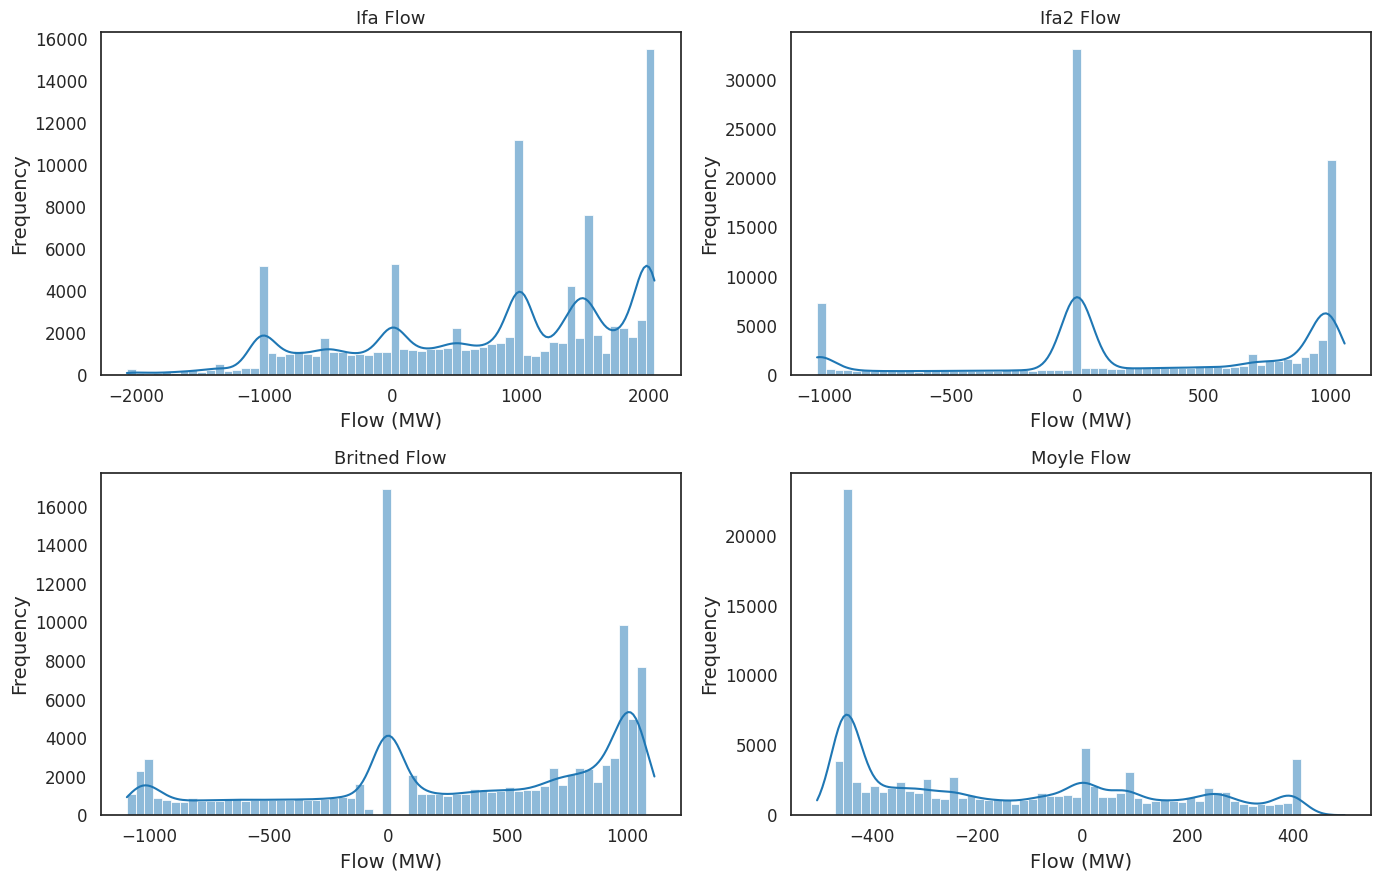

In [ ]:
# Phân phối các cột dòng liên kết (interconnector flows), chưa được khảo sát ở notebook trước
cot_dong_lien_ket = ["IFA_FLOW", "IFA2_FLOW", "BRITNED_FLOW", "MOYLE_FLOW"]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, col in zip(axes.ravel(), cot_dong_lien_ket):
    sns.histplot(df[col], bins=60, kde=True, ax=ax, color="tab:blue")
    ax.set_title(col.replace("_", " ").title(), fontsize=13)
    ax.set_xlabel("Flow (MW)")
    ax.set_ylabel("Frequency")

#title:Distribution of Interconnector Flow Columns
plt.tight_layout()
save_figure(fig, "fig_1_distribution_interconnector_flows")
plt.show()


**Nhận xét**

Các cột dòng liên kết thể hiện phân phối đa đỉnh hoặc lệch rõ rệt, phản ánh bản chất vận hành theo hợp đồng thương mại (import/export theo lịch trình) hơn là một quá trình vật lý liên tục như nhu cầu điện. Đặc điểm này cần được lưu ý khi diễn giải hệ số tương quan Pearson ở mục 4.4, vì một biến có phân phối đa đỉnh có thể cho hệ số Pearson thấp ngay cả khi tồn tại quan hệ phi tuyến với nhu cầu điện.

## 4.2 Time-based Analysis

### 4.2.1 Kiểm định tính dừng (Stationarity Testing)

### 2.1 Kiểm định Augmented Dickey Fuller trên chuỗi gốc

Kiểm định ADF có giả thuyết gốc H0 cho rằng chuỗi tồn tại nghiệm đơn vị, tức không dừng, và giả thuyết đối H1 cho rằng chuỗi có tính dừng. Giá trị p nhỏ hơn ngưỡng ý nghĩa 0,05 cho phép bác bỏ H0 và kết luận chuỗi có tính dừng.

In [ ]:
def kiem_dinh_adf(chuoi, ten_chuoi):
    ket_qua = adfuller(chuoi.dropna(), autolag="AIC")
    thong_ke = {
        "Chuỗi": ten_chuoi,
        "Thống kê ADF": ket_qua[0],
        "Giá trị p": ket_qua[1],
        "Số độ trễ sử dụng": ket_qua[2],
        "Số quan trắc": ket_qua[3],
        "Giá trị tới hạn 1%": ket_qua[4]["1%"],
        "Giá trị tới hạn 5%": ket_qua[4]["5%"],
        "Kết luận": "Dừng" if ket_qua[1] < 0.05 else "Không dừng",
    }
    return thong_ke

cac_chuoi_can_kiem_dinh = ["ND", "TSD", "ENGLAND_WALES_DEMAND"]
ket_qua_adf_goc = pd.DataFrame([kiem_dinh_adf(df[c], c) for c in cac_chuoi_can_kiem_dinh])
ket_qua_adf_goc

,Chuỗi,Thống kê ADF,Giá trị p,Số độ trễ sử dụng,Số quan trắc,Giá trị tới hạn 1%,Giá trị tới hạn 5%,Kết luận
0,ND,-14.1875,0.0000,69,105146,-3.4304,-2.8616,Dừng
1,TSD,-15.1984,0.0000,67,105148,-3.4304,-2.8616,Dừng
2,ENGLAND_WALES_DEMAND,-13.6185,0.0000,69,105146,-3.4304,-2.8616,Dừng


**Nhận xét**

Cả ba chuỗi nhu cầu điện lõi đều bác bỏ giả thuyết H0 với giá trị p rất nhỏ, cho thấy chuỗi ở dạng mức gốc đã mang tính dừng theo kiểm định ADF, mặc dù chuỗi thể hiện tính mùa vụ mạnh theo ngày, theo tuần và theo năm quan sát được ở notebook trước. Kết quả này không mâu thuẫn với sự hiện diện của mùa vụ, vì kiểm định ADF chỉ kiểm tra sự tồn tại của nghiệm đơn vị mang bản chất ngẫu nhiên bước đi ngẫu nhiên, trong khi tính mùa vụ là một thành phần tất định lặp lại đều đặn, không làm phương sai của chuỗi tăng dần theo thời gian. Do chuỗi đã dừng ở mức gốc, các mô hình được đề xuất trong Research Proposal như Random Forest, XGBoost và LightGBM có thể sử dụng trực tiếp giá trị ND làm biến mục tiêu mà không bắt buộc phải lấy sai phân trước khi đưa vào huấn luyện.

**Lưu ý về sức mạnh kiểm định:** với số quan trắc lên tới 105.216 dòng, kiểm định ADF gần như luôn bác bỏ H0 ở bất kỳ chuỗi thực tế nào có độ nhiễu hữu hạn, kể cả khi chuỗi chứa một thành phần xu hướng chậm. Do đó giá trị p rất nhỏ ở đây nên được đọc là *không có bằng chứng của nghiệm đơn vị dạng bước đi ngẫu nhiên*, chứ không phải bằng chứng cho rằng chuỗi hoàn toàn không có xu hướng. Thật vậy, phân rã MSTL ở mục 4.3 sẽ chỉ ra một thành phần xu hướng (trend) có tỷ trọng phương sai nhỏ nhưng khác không; điều này **không mâu thuẫn** với kết luận dừng ở đây, vì ADF chỉ loại trừ nghiệm đơn vị ngẫu nhiên chứ không kiểm định sự vắng mặt của một xu hướng tất định có biên độ giới hạn.

### 2.2 Kiểm định trên chuỗi sai phân bậc một

Nhằm đối chiếu và củng cố kết luận ở mục 2.1, kiểm định ADF được lặp lại trên chuỗi sai phân bậc một của ND, tức hiệu số giữa hai chu kỳ quyết toán liên tiếp, đại diện cho tốc độ thay đổi nhu cầu điện giữa hai lần đo cách nhau 30 phút.

In [ ]:
chuoi_sai_phan = df["ND"].diff().dropna()
ket_qua_adf_sai_phan = pd.DataFrame([kiem_dinh_adf(chuoi_sai_phan, "ND (sai phân bậc một)")])
ket_qua_adf_sai_phan

,Chuỗi,Thống kê ADF,Giá trị p,Số độ trễ sử dụng,Số quan trắc,Giá trị tới hạn 1%,Giá trị tới hạn 5%,Kết luận
0,ND (sai phân bậc một),-39.0927,0.0000,69,105145,-3.4304,-2.8616,Dừng


**Nhận xét**

Chuỗi sai phân bậc một của ND cho thống kê ADF càng âm hơn và giá trị p càng nhỏ hơn so với chuỗi gốc, khẳng định chuỗi sai phân dừng với mức độ tin cậy còn cao hơn. Kết quả này phù hợp về mặt lý thuyết, vì việc lấy sai phân thường làm tăng cường tính dừng của một chuỗi vốn đã dừng ở mức gốc. Tuy nhiên do mục 2.1 đã xác nhận ND dừng ở mức gốc, notebook giữ nguyên đơn vị MW của ND xuyên suốt các bước phân tích tiếp theo và không sử dụng chuỗi sai phân làm biến mục tiêu chính thức của mô hình.

### 4.2.2 Phân tích tự tương quan (ACF và PACF)

### 3.1 Hình ảnh ACF và PACF kết hợp (Hình ảnh chẩn đoán kết hợp)

Ba hình ảnh về ACF ngắn hạn, ACF dài hạn và PACF trong phần trước chiếm gần hai trang khi được nhúng vào bản thảo LaTeX (PACF có chiều rộng 1.0, hai bảng ACF mỗi bảng có chiều rộng văn bản là 0.90), trong khi hình ảnh đường ống mô tả toàn bộ phương pháp chỉ có chiều rộng văn bản là 0.45. Phần này kết hợp cả ba phân đoạn tương quan thành một hình ảnh duy nhất gồm ba bảng đặt cạnh nhau: bảng bên trái là phân đoạn chuỗi thời gian cơ sở để so sánh trực quan, bảng ở giữa là hàm tương quan ACF được tính toán trên toàn bộ chuỗi và được khảo sát trong phạm vi hai tuần để bao phủ cả hai chu kỳ ngày-tuần, và bảng bên phải là hàm tương quan PACF được khảo sát riêng biệt trong hai ngày liên tiếp. Cách trình bày này giữ lại tất cả nội dung chẩn đoán đã có trong ba hình ảnh trước đó trong khi giảm diện tích trang chiếm dụng xuống một phần ba.

Da luu hinh: figures/acf_pacf_combined.png


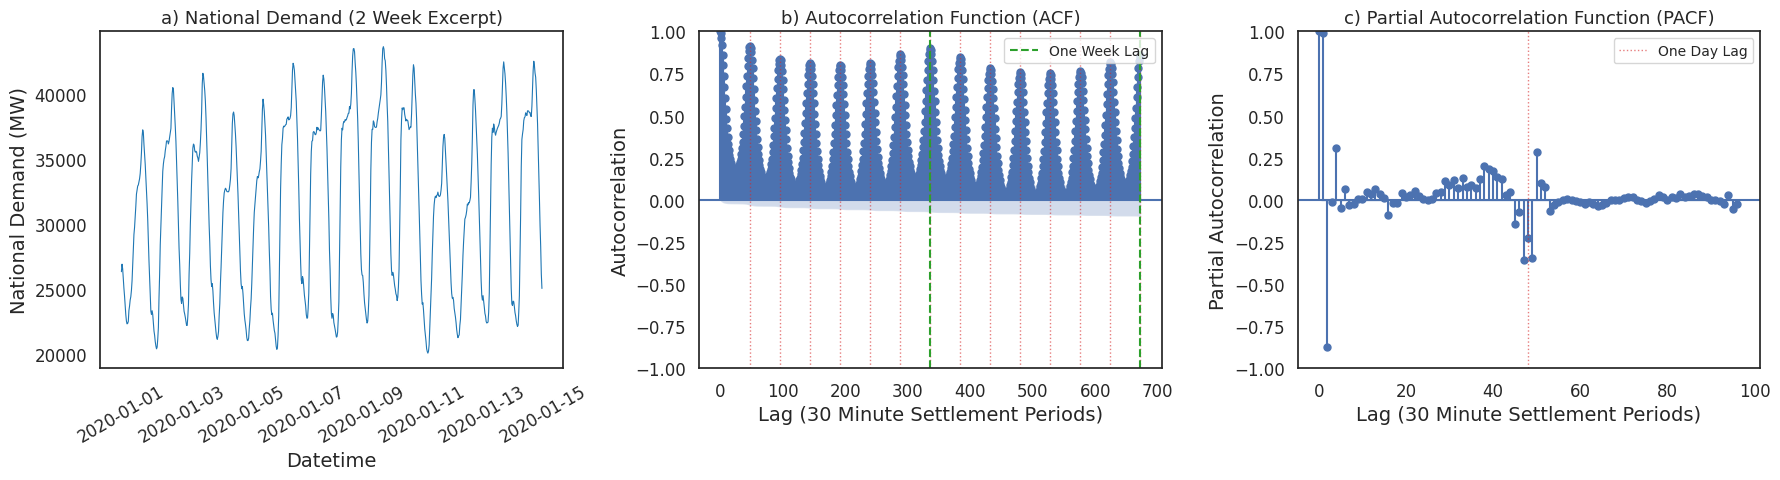

In [ ]:
so_do_tre_acf = CHU_KY_MOT_TUAN * 2  # 672, 2 tuan, bao quat ca chu ky ngay va chu ky tuan
so_do_tre_pacf = 96  # 2 ngay

cua_so_hien_thi = CHU_KY_MOT_TUAN * 2  # doan chuoi hien thi cung do dai voi cua so ACF
chuoi_hien_thi = df["ND"].iloc[:cua_so_hien_thi]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

#  Panel 1: Time Series (doan du lieu goc, 2 tuan dau)
axes[0].plot(chuoi_hien_thi.index, chuoi_hien_thi.values, color="tab:blue", linewidth=0.8)
axes[0].set_title("a) National Demand (2 Week Excerpt)", fontsize=13)
axes[0].set_xlabel("Datetime")
axes[0].set_ylabel("National Demand (MW)")
axes[0].tick_params(axis="x", rotation=30)
axes[0].grid(False)

#  Panel 2: ACF, tinh tren toan bo chuoi, khao sat 2 tuan do tre
plot_acf(df["ND"], lags=so_do_tre_acf, ax=axes[1], title="")
for boi_so in range(1, so_do_tre_acf // CHU_KY_MOT_NGAY + 1):
    axes[1].axvline(boi_so * CHU_KY_MOT_NGAY, color="tab:red", linestyle=":", linewidth=1, alpha=0.6)
axes[1].axvline(CHU_KY_MOT_TUAN, color="tab:green", linestyle="--", linewidth=1.5, label="One Week Lag")
axes[1].axvline(CHU_KY_MOT_TUAN * 2, color="tab:green", linestyle="--", linewidth=1.5)
axes[1].set_title("b) Autocorrelation Function (ACF)", fontsize=13)
axes[1].set_xlabel("Lag (30 Minute Settlement Periods)")
axes[1].set_ylabel("Autocorrelation")
axes[1].legend(loc="upper right", fontsize=10)
axes[1].grid(False)

# Panel 3: PACF, khao sat 2 ngay dau tien
plot_pacf(df["ND"], lags=so_do_tre_pacf, ax=axes[2], method="ywm", title="")
axes[2].axvline(CHU_KY_MOT_NGAY, color="tab:red", linestyle=":", linewidth=1, alpha=0.6, label="One Day Lag")
axes[2].set_title("c) Partial Autocorrelation Function (PACF)", fontsize=13)
axes[2].set_xlabel("Lag (30 Minute Settlement Periods)")
axes[2].set_ylabel("Partial Autocorrelation")
axes[2].legend(loc="upper right", fontsize=10)
axes[2].grid(False)

for ax in axes:
    ax.grid(False)

plt.tight_layout()

import os as _os
_os.makedirs("figures", exist_ok=True)
# SUA (uu tien 3, docx #3): doi sang PDF vector (khong con dpi hữu hạn) thay vi PNG 300dpi -- ACF/PACF la hinh ve duong, Springer yeu cau 600dpi cho loai nay, PDF vector thoa man ma khong can chon dpi.
fig.savefig("figures/acf_pacf_combined.pdf", bbox_inches="tight")
# Giu them ban PNG 600dpi (rcParams savefig.dpi mac dinh) de xem nhanh/README, khong dung ban nay trong main.tex.
fig.savefig("figures/acf_pacf_combined.png", bbox_inches="tight")
print("Da luu hinh: figures/acf_pacf_combined.pdf (vector, dung trong paper) va .png (xem nhanh)")

plt.show()


**Nhận xét**

Hình gộp này thay thế ba hình riêng lẻ của bản trước theo đúng góp ý phản biện: pipeline chỉ chiếm 0,45 textwidth trong khi ba hình chẩn đoán tự tương quan chiếm gần hai trang. Ở cấu hình mới, cả ba nội dung chẩn đoán nằm trên một hàng duy nhất mà không mất thông tin.

Panel bên trái cho thấy trực tiếp trên đoạn dữ liệu hai tuần đầu tiên một dạng sóng lặp lại rất đều theo từng ngày, với biên độ ngày cuối tuần thấp hơn rõ rệt so với các ngày trong tuần, đây chính là hiện tượng mà hai panel bên phải sẽ định lượng bằng con số.

Panel giữa là ACF tính trên toàn bộ 105.216 quan trắc, khảo sát 672 độ trễ tương ứng hai tuần. Hệ số tự tương quan giảm từ 0,9895 tại độ trễ 1 xuống vùng đáy cục bộ quanh 0,80 tại độ trễ 192 đến 240 (ngày thứ tư, thứ năm), rồi tăng trở lại và đạt đỉnh cục bộ 0,9007 tại đúng độ trễ 336, tức một tuần. Đỉnh này cao hơn rõ rệt so với hai đỉnh ngày lân cận cùng thuộc bội số của 48 nhưng lệch thứ trong tuần, cụ thể 0,8638 tại độ trễ 288 (thứ Sáu so Chủ Nhật gốc) và 0,8469 tại độ trễ 384 (thứ Ba so Chủ Nhật gốc). Kết quả này xác nhận tồn tại một chu kỳ tuần lồng bên trong chu kỳ ngày, đúng như bản trước đã kết luận, nay được đo trên một cửa sổ duy nhất thay vì hai hình tách rời.

Panel bên phải là PACF khảo sát 96 độ trễ đầu tiên bằng phương pháp Yule Walker hiệu chỉnh. Giá trị tại độ trễ 1 đạt 0,9895 và tại độ trễ 2 đạt âm 0,8697, hai con số lớn về độ lớn và trái dấu nhau cho thấy một cơ chế điều chỉnh bậc hai mạnh giữa hai chu kỳ 30 phút liên tiếp. Từ độ trễ 3 trở đi giá trị PACF rơi gần về 0 (âm 0,0133), khẳng định phần tương quan còn lại ở các độ trễ ngắn đã được giải thích hết qua hai độ trễ đầu. Một đỉnh phụ xuất hiện tại độ trễ 48 và 49 với giá trị lần lượt âm 0,2278 và âm 0,347, phản ánh phần đóng góp trực tiếp của cùng khung giờ hôm trước, không thể giải thích gián tiếp qua các độ trễ trung gian.

Ba panel cùng xác nhận độc lập rằng độ trễ 48 và độ trễ 336 là hai mốc thời gian có ý nghĩa thống kê mạnh nhất trong toàn chuỗi, đúng bằng công thức của hai đường cơ sở SNaive Daily và SNaive Weekly, đồng thời việc ACF suy giảm chậm còn PACF suy giảm nhanh sau hai độ trễ đầu là dấu hiệu điển hình của một quá trình có thành phần tự hồi quy bậc thấp cộng với thành phần mùa vụ mạnh, phù hợp với quyết định dùng tập đặc trưng trễ chọn lọc ($H \in \{1,2,12,24,36,48\}$ và $H=336$) thay vì đưa hàng chục độ trễ tự hồi quy trực tiếp vào các mô hình cây.

## 4.3 Seasonality Analysis

### 4.3.1 Phân rã tín hiệu đa mùa vụ bằng MSTL

Kết quả ở Bước 3 xác nhận nhu cầu điện chịu ảnh hưởng đồng thời của hai chu kỳ mùa vụ lồng nhau: chu kỳ ngày với độ dài 48 chu kỳ quyết toán và chu kỳ tuần với độ dài 336 chu kỳ quyết toán. Phương pháp MSTL, tức Multiple Seasonal Trend decomposition using Loess, cho phép phân rã đồng thời cả hai thành phần mùa vụ này cùng với thành phần xu hướng và phần dư, mà không cần biến đổi chuỗi hay lặp lại phân rã STL đơn mùa vụ nhiều lần.

In [ ]:
mstl = MSTL(df["ND"], periods=[CHU_KY_MOT_NGAY, CHU_KY_MOT_TUAN])
ket_qua_mstl = mstl.fit()

thanh_phan = pd.DataFrame({
    "trend": ket_qua_mstl.trend,
    "seasonal_daily": ket_qua_mstl.seasonal["seasonal_48"],
    "seasonal_weekly": ket_qua_mstl.seasonal["seasonal_336"],
    "resid": ket_qua_mstl.resid,
})

thanh_phan.head()

,trend,seasonal_daily,seasonal_weekly,resid
DATETIME,,,,
2020-01-01 00:00:00,"29,236.3532","-6,237.8632",979.6599,"2,361.8501"
2020-01-01 00:30:00,"29,247.2646","-5,910.9958","1,157.1990","2,427.5323"
2020-01-01 01:00:00,"29,258.1651","-6,288.2659","1,167.8089","2,431.2919"
2020-01-01 01:30:00,"29,269.0547","-6,988.8405","1,133.6022","2,340.1836"
2020-01-01 02:00:00,"29,279.9333","-7,601.6142","1,196.0291","2,200.6518"


#### Trực quan hóa các thành phần phân rã

Đã lưu hình: figures/fig_5_mstl_decomposition.png


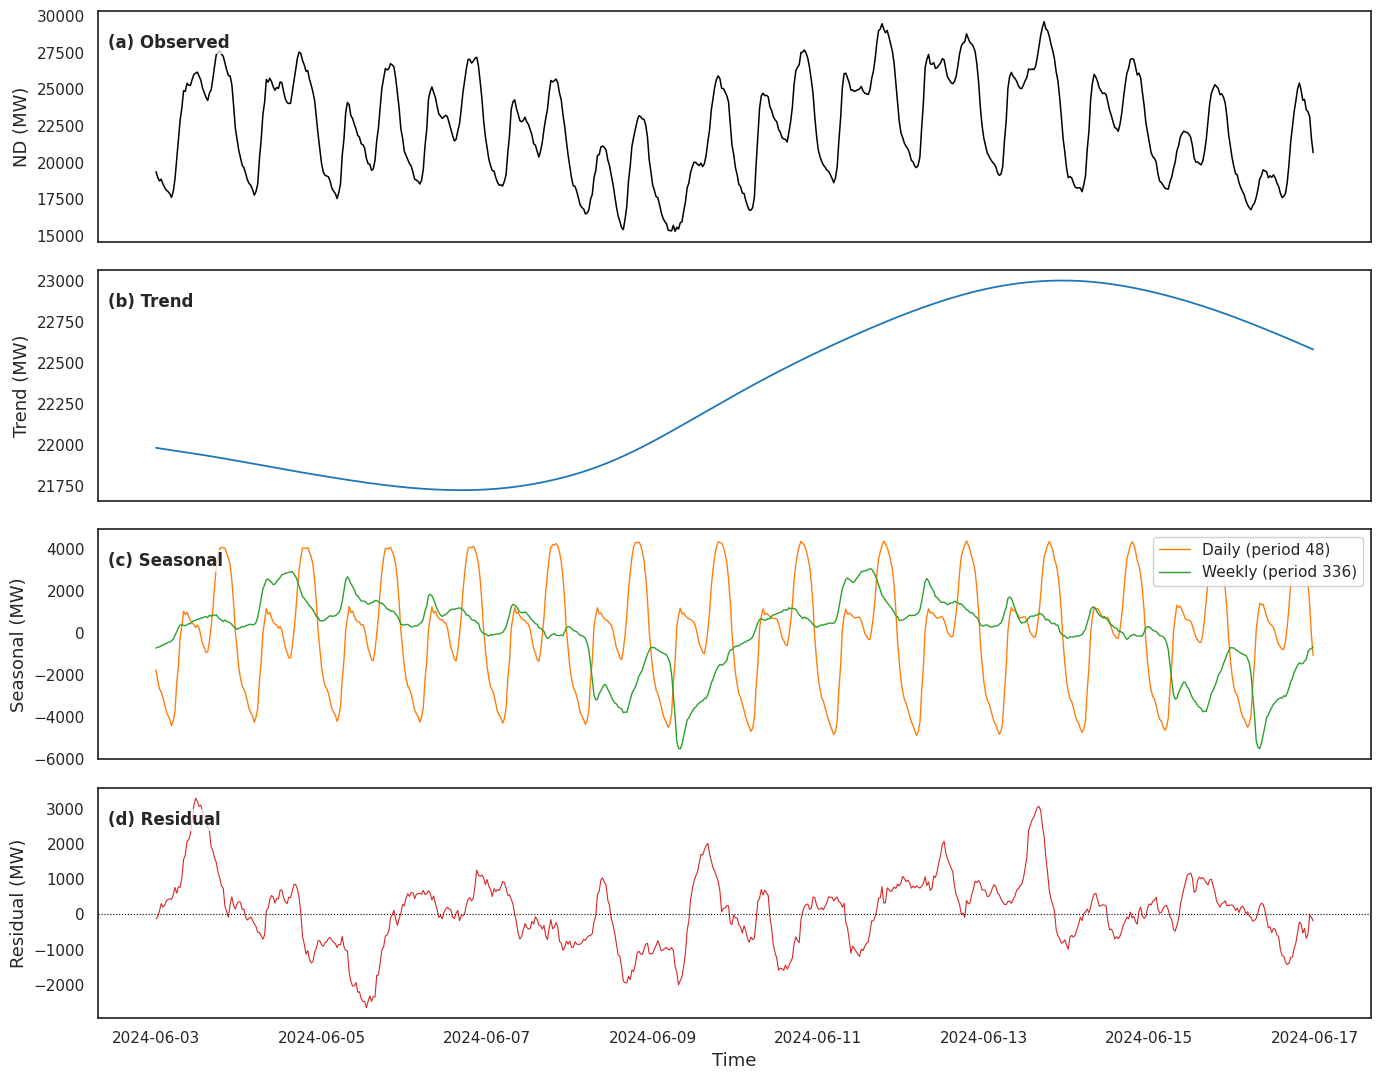

In [ ]:
# ===== MSTL decomposition — HÌNH NÀY NHÚNG VÀO PAPER (mstl_decomposition.png) =====
# SỬA: bỏ title của từng subplot. main.tex đã có \caption giải thích đầy đủ bên dưới
# hình rồi, để thêm 4 dòng title in đậm nữa là dư thừa và làm rối hình.
# Thay bằng nhãn góc (a)/(b)/(c)/(d) — chuẩn hay dùng trong hình khoa học.
tuan_minh_hoa = thanh_phan.loc["2024-06-03":"2024-06-16"]

fig, axes = plt.subplots(4, 1, figsize=(14, 11), sharex=True)
panel_labels = ["(a) Observed", "(b) Trend", "(c) Seasonal", "(d) Residual"]

axes[0].plot(df.loc[tuan_minh_hoa.index, "ND"], color="black", linewidth=1.1)
axes[0].set_ylabel("ND (MW)", fontsize=13)

axes[1].plot(tuan_minh_hoa["trend"], color="tab:blue", linewidth=1.3)
axes[1].set_ylabel("Trend (MW)", fontsize=13)

axes[2].plot(tuan_minh_hoa["seasonal_daily"], color="tab:orange", linewidth=1, label="Daily (period 48)")
axes[2].plot(tuan_minh_hoa["seasonal_weekly"], color="tab:green", linewidth=1, label="Weekly (period 336)")
axes[2].set_ylabel("Seasonal (MW)", fontsize=13)
axes[2].legend(loc="upper right", fontsize=11, framealpha=0.9)

axes[3].plot(tuan_minh_hoa["resid"], color="tab:red", linewidth=0.8)
axes[3].axhline(0, color="black", linewidth=0.8, linestyle=":")
axes[3].set_ylabel("Residual (MW)", fontsize=13)
axes[3].set_xlabel("Time", fontsize=13)

for ax, label in zip(axes, panel_labels):
    ax.text(0.008, 0.90, label, transform=ax.transAxes, fontsize=12,
            fontweight="bold", va="top", ha="left",
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, pad=1.5))
    ax.tick_params(labelsize=11)

plt.tight_layout()
save_figure(fig, "fig_5_mstl_decomposition", also_pdf=True)  # SUA uu tien 3, docx #3: ban PDF vector
plt.show()

**Nhận xét**

Thành phần xu hướng biến động mượt mà và chậm rãi, phản ánh sự thay đổi nhu cầu điện nền qua từng tuần chứ không mang tính chu kỳ ngắn hạn. Thành phần mùa vụ ngày có biên độ dao động lớn hơn nhiều so với thành phần mùa vụ tuần và lặp lại hình dạng hai đỉnh cao điểm sáng và tối đã phát hiện ở phân tích song biến của notebook trước, trong khi thành phần mùa vụ tuần thể hiện rõ mức nền thấp hơn vào hai ngày cuối tuần so với năm ngày làm việc. Phần dư dao động quanh mức không mà không thể hiện quy luật lặp lại rõ ràng, cho thấy hai chu kỳ mùa vụ 48 và 336 đã giải thích được phần lớn cấu trúc có tính lặp lại của tín hiệu nhu cầu điện, phần biến động còn lại trong phần dư nhiều khả năng gắn với các yếu tố phi định kỳ như điều kiện thời tiết bất thường hoặc ngày lễ, đúng như đã lập luận trong bản đồ giả thuyết của notebook trước.

#### Định lượng tỷ trọng đóng góp của từng thành phần

In [ ]:
phuong_sai_quan_trac = df["ND"].var()
phuong_sai_trend = thanh_phan["trend"].var()
phuong_sai_mua_ngay = thanh_phan["seasonal_daily"].var()
phuong_sai_mua_tuan = thanh_phan["seasonal_weekly"].var()
phuong_sai_du = thanh_phan["resid"].var()

bang_ty_trong = pd.DataFrame({
    "Thành phần": ["Xu hướng (Trend)", "Mùa vụ ngày (Seasonal Daily)", "Mùa vụ tuần (Seasonal Weekly)", "Phần dư (Residual)"],
    "Phương sai": [phuong_sai_trend, phuong_sai_mua_ngay, phuong_sai_mua_tuan, phuong_sai_du],
})
bang_ty_trong["Tỷ trọng so với phương sai quan trắc (%)"] = (bang_ty_trong["Phương sai"] / phuong_sai_quan_trac * 100).round(2)
bang_ty_trong

,Thành phần,Phương sai,Tỷ trọng so với phương sai quan trắc (%)
0,Xu hướng (Trend),"14,849,670.0102",38.4100
1,Mùa vụ ngày (Seasonal Daily),"18,735,349.8474",48.4600
2,Mùa vụ tuần (Seasonal Weekly),"3,107,374.7686",8.0400
3,Phần dư (Residual),"1,297,864.8695",3.3600


**Nhận xét**

Bảng định lượng xác nhận thành phần mùa vụ ngày chiếm tỷ trọng phương sai lớn nhất trong bốn thành phần, khẳng định lại bằng con số cụ thể phát hiện định tính đã nêu ở mục 4.2 rằng nhịp sinh hoạt trong ngày là yếu tố chi phối mạnh nhất đối với biến động nhu cầu điện. Thành phần mùa vụ tuần tuy có tỷ trọng nhỏ hơn nhưng vẫn đóng góp đáng kể, đủ để biện minh cho việc giữ lại đặc trưng ngày trong tuần và cờ cuối tuần trong tập đặc trưng mô hình theo đúng đề xuất ở Research Proposal. Tỷ trọng phần dư ở mức tương đối thấp cho thấy phần lớn tín hiệu có thể được giải thích bằng các quy luật tất định theo lịch, củng cố cơ sở cho hướng tiếp cận dự báo dựa trên đặc trưng thời gian tuần hoàn thay vì mô hình chuỗi thời gian tự hồi quy phức tạp.

### 4.3.2 Mùa vụ theo tháng (Monthly Seasonality)

ACF, PACF và MSTL ở trên định lượng hai chu kỳ mùa vụ ngắn: ngày (48 chu kỳ) và tuần (336 chu kỳ). Ở tần suất 30 phút, chu kỳ năm quá dài để quan sát trực tiếp qua ACF trong phạm vi vài nghìn độ trễ đã khảo sát, nên mùa vụ theo tháng được kiểm tra riêng bằng cách gộp nhu cầu điện trung bình theo từng tháng dương lịch, tách theo từng năm quan sát.

Đã lưu hình: figures/fig_6_monthly_seasonality.png


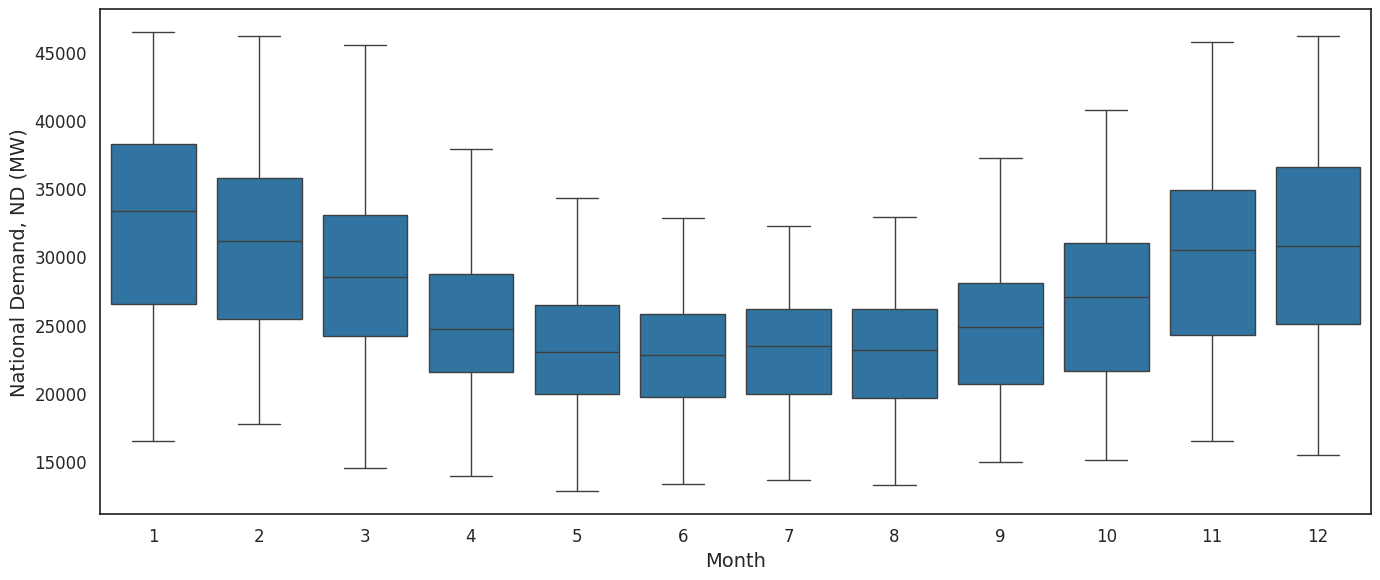

In [ ]:
# Mùa vụ theo tháng: trung bình ND theo tháng dương lịch, tách theo từng năm
df_thang = df.copy()
df_thang["Nam"] = df_thang.index.year
df_thang["Thang"] = df_thang.index.month

fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(data=df_thang, x="Thang", y="ND", ax=ax, color="tab:blue", fliersize=2)
#title:Monthly Seasonality of National Demand (2020 to 2025)
ax.set_xlabel("Month")
ax.set_ylabel("National Demand, ND (MW)")
plt.tight_layout()
save_figure(fig, "fig_6_monthly_seasonality")
plt.show()


**Nhận xét**

Nhu cầu điện trung bình đạt đỉnh vào các tháng mùa đông (tháng Mười Hai, Một, Hai) và xuống thấp nhất vào các tháng mùa hè (tháng Sáu, Bảy), nhất quán với mô hình khí hậu ôn đới của Great Britain đã nêu ở notebook trước. Độ phân tán trong mỗi tháng (chiều cao hộp boxplot) cũng lớn hơn ở các tháng mùa đông, phản ánh biến động nhu cầu sưởi ấm nhạy với thời tiết cực đoan hơn là biến động do làm mát mùa hè. Phát hiện này bổ sung một chu kỳ mùa vụ thứ ba (theo năm) bên cạnh hai chu kỳ ngày và tuần đã định lượng ở trên, dù chu kỳ năm không được đưa vào đặc trưng mã hoá tuần hoàn ở notebook tiếp theo do giới hạn độ dài chuỗi quan sát.

## 4.4 Correlation Analysis

### 4.4.1 Ma trận tương quan giữa nhu cầu điện và các thuộc tính hệ thống

Đã lưu hình: figures/fig_7_correlation_heatmap.png


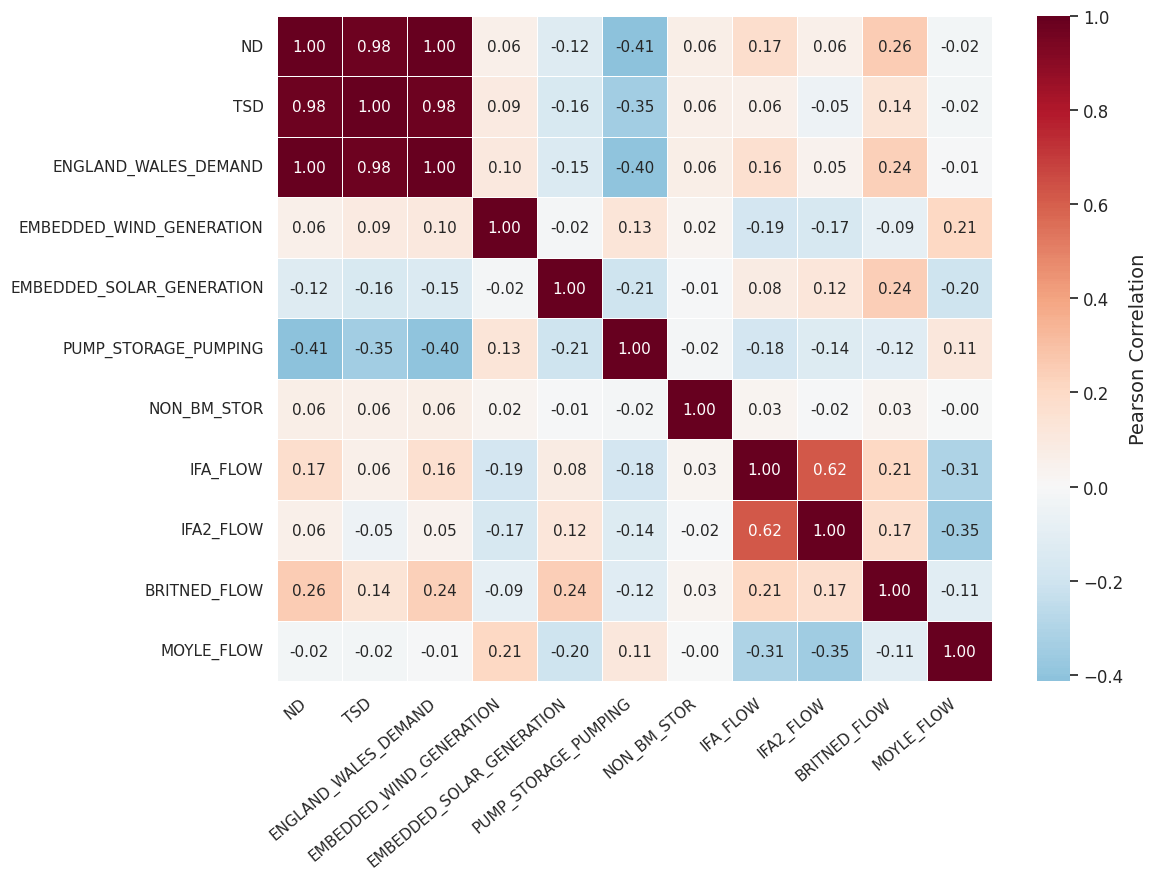

In [ ]:
cot_tuong_quan = [
    "ND", "TSD", "ENGLAND_WALES_DEMAND",
    "EMBEDDED_WIND_GENERATION", "EMBEDDED_SOLAR_GENERATION",
    "PUMP_STORAGE_PUMPING", "NON_BM_STOR",
    "IFA_FLOW", "IFA2_FLOW", "BRITNED_FLOW", "MOYLE_FLOW",
]

ma_tran_tuong_quan = df[cot_tuong_quan].corr(method="pearson")

plt.figure(figsize=(12, 9))
sns.heatmap(ma_tran_tuong_quan, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            linewidths=0.5, annot_kws={"size": 11},
            cbar_kws={"label": "Pearson Correlation"})
#title: Correlation: National Demand vs. System Attributes
plt.xticks(rotation=40, ha="right", fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
save_figure(plt.gcf(), "fig_7_correlation_heatmap")
plt.show()

**Nhận xét**

Ma trận tương quan tiếp tục xác nhận ba cột nhu cầu lõi ND, TSD và ENGLAND_WALES_DEMAND tương quan gần như tuyệt đối với nhau, đúng như đã phát hiện ở notebook trước. Trong nhóm năng lượng tái tạo nhúng, sản lượng điện mặt trời thể hiện tương quan âm ở mức trung bình với ND, trong khi sản lượng điện gió thể hiện tương quan gần như bằng không hoặc dương rất yếu, một phát hiện nhất quán với kết quả kiểm định giả thuyết H5 đã trình bày trước đây. Đây là bằng chứng tương quan tuyến tính đồng thời tại cùng một thời điểm, tuy nhiên vì cả nhu cầu điện lẫn sản lượng tái tạo đều là chuỗi thời gian có quán tính, mối liên hệ thực sự giữa hai đại lượng này có thể xảy ra lệch pha theo thời gian, cần được khảo sát thêm bằng tương quan chéo ở mục 5.2.

### 4.4.2 Tương quan chéo giữa nhu cầu điện và năng lượng mặt trời nhúng

Hàm tương quan chéo, viết tắt CCF, đo mức độ tương quan giữa hai chuỗi khi một trong hai chuỗi được dịch chuyển tới hoặc lùi theo thời gian một số độ trễ nhất định, cho phép phát hiện mối quan hệ dạng dẫn dắt hoặc trễ pha mà tương quan tức thời ở mục 5.1 không thể hiện được.

Đã lưu hình: figures/fig_8_ccf_solar.png


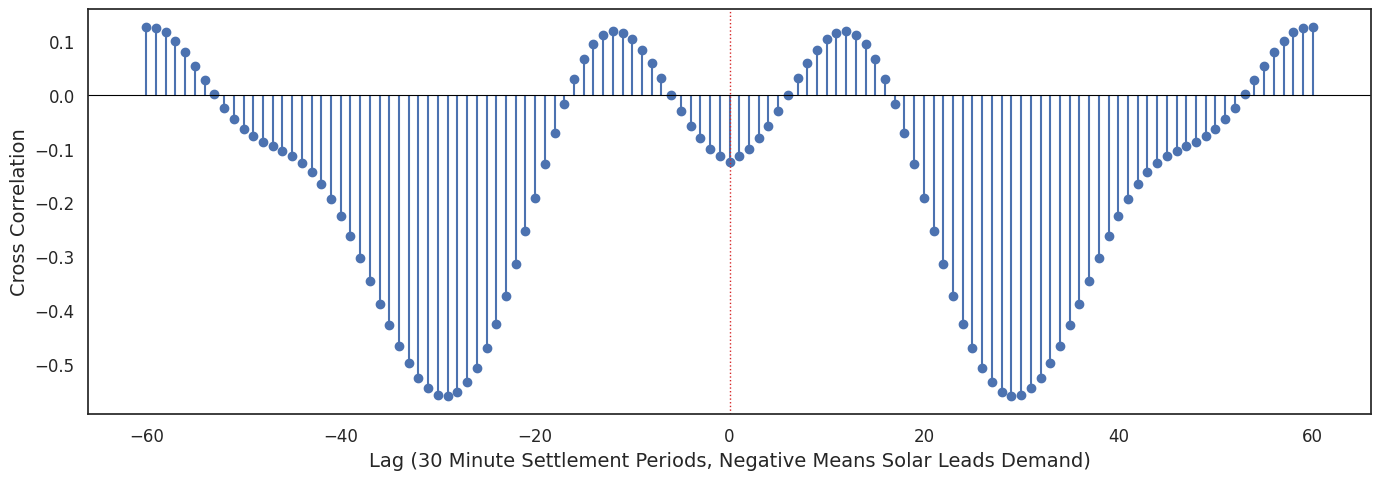

Độ trễ có tương quan mạnh nhất: -29 chu kỳ, giá trị tương quan: -0.5593


In [ ]:
def tinh_tuong_quan_cheo(x, y, do_tre_toi_da):
    danh_sach_do_tre = list(range(-do_tre_toi_da, do_tre_toi_da + 1))
    danh_sach_gia_tri = []
    for do_tre in danh_sach_do_tre:
        if do_tre < 0:
            danh_sach_gia_tri.append(x.corr(y.shift(-do_tre)))
        else:
            danh_sach_gia_tri.append(x.corr(y.shift(do_tre)))
    return pd.Series(danh_sach_gia_tri, index=danh_sach_do_tre)

DO_TRE_TOI_DA = 60  # 30 giờ mỗi hướng

ccf_solar = tinh_tuong_quan_cheo(df["ND"], df["EMBEDDED_SOLAR_GENERATION"], DO_TRE_TOI_DA)

plt.figure(figsize=(14, 5))
plt.stem(ccf_solar.index, ccf_solar.values, basefmt=" ")
plt.axhline(0, color="black", linewidth=0.8)
plt.axvline(0, color="tab:red", linestyle=":", linewidth=1)
#title: Cross Correlation Between National Demand and Embedded Solar Generation
plt.xlabel("Lag (30 Minute Settlement Periods, Negative Means Solar Leads Demand)")
plt.ylabel("Cross Correlation")
plt.tight_layout()
save_figure(plt.gcf(), "fig_8_ccf_solar")
plt.show()

do_tre_manh_nhat = ccf_solar.abs().idxmax()
print(f"Độ trễ có tương quan mạnh nhất: {do_tre_manh_nhat} chu kỳ, giá trị tương quan: {ccf_solar[do_tre_manh_nhat]:.4f}")

**Nhận xét**

Đồ thị tương quan chéo cho thấy mối liên hệ giữa sản lượng điện mặt trời nhúng và nhu cầu điện không đạt cực trị tại độ trễ bằng không, mà tại một độ trễ âm, tức sản lượng mặt trời dẫn dắt trước nhu cầu đo được trên lưới truyền tải. Hình dạng này phù hợp với cơ chế vận hành thực tế: sản lượng điện mặt trời tăng dần từ giữa buổi sáng, sớm hơn thời điểm nhu cầu ròng trên lưới truyền tải chạm đáy giữa ngày, bởi nhu cầu ròng chỉ giảm sau khi sản lượng mặt trời tích lũy đủ lớn để bù đắp đáng kể cho phụ tải tại chỗ. Phát hiện lệch pha này là căn cứ định lượng cho câu hỏi RQ4 của Research Proposal, gợi ý rằng nếu mô hình dự báo muốn khai thác tối đa thông tin từ năng lượng tái tạo nhúng, có thể cân nhắc thêm phiên bản trễ của biến sản lượng mặt trời bên cạnh giá trị tức thời đã liệt kê trong tập đặc trưng.

### 4.4.3 Tương quan chéo giữa nhu cầu điện và năng lượng gió nhúng

Đã lưu hình: figures/fig_9_ccf_wind.png


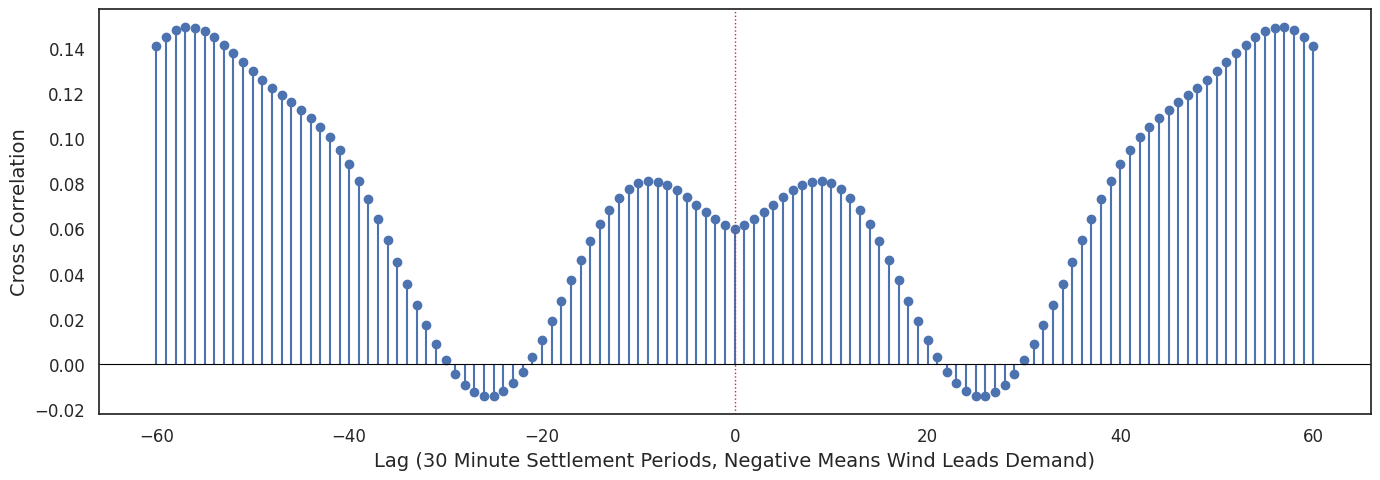

Độ trễ có tương quan mạnh nhất: -57 chu kỳ, giá trị tương quan: 0.1490


In [ ]:
ccf_wind = tinh_tuong_quan_cheo(df["ND"], df["EMBEDDED_WIND_GENERATION"], DO_TRE_TOI_DA)

plt.figure(figsize=(14, 5))
plt.stem(ccf_wind.index, ccf_wind.values, basefmt=" ")
plt.axhline(0, color="black", linewidth=0.8)
plt.axvline(0, color="tab:red", linestyle=":", linewidth=1)
#title: Cross Correlation Between National Demand and Embedded Wind Generation
plt.xlabel("Lag (30 Minute Settlement Periods, Negative Means Wind Leads Demand)")
plt.ylabel("Cross Correlation")
plt.tight_layout()
save_figure(plt.gcf(), "fig_9_ccf_wind")
plt.show()

do_tre_manh_nhat_gio = ccf_wind.abs().idxmax()
print(f"Độ trễ có tương quan mạnh nhất: {do_tre_manh_nhat_gio} chu kỳ, giá trị tương quan: {ccf_wind[do_tre_manh_nhat_gio]:.4f}")

**Nhận xét**

Khác với sản lượng điện mặt trời, tương quan chéo giữa sản lượng điện gió nhúng và nhu cầu điện duy trì biên độ thấp và tương đối bằng phẳng trên toàn bộ dải độ trễ được khảo sát, không thể hiện một đỉnh lệch pha rõ rệt như trường hợp điện mặt trời. Điều này phù hợp với bản chất vật lý của nguồn gió, vốn phụ thuộc vào điều kiện khí tượng biến đổi liên tục theo giờ và theo ngày mà không đồng bộ với chu kỳ ngày đêm của nhu cầu điện, khác hẳn với chu kỳ mặt trời vốn luôn gắn chặt với giờ trong ngày. Kết quả này củng cố khuyến nghị trong Research Proposal về việc đưa sản lượng điện gió và sản lượng điện mặt trời vào mô hình như hai đặc trưng tách biệt thay vì gộp chung thành một biến năng lượng tái tạo tổng hợp duy nhất.

# 5. Key Insights

**Tóm tắt phát hiện chính**

- **Phạm vi dữ liệu:** toàn bộ phân tích trong notebook này đại diện cho **Great Britain (GB)** - England, Wales, Scotland ,không bao gồm Northern Ireland (thuộc SEM), theo đúng phạm vi công bố của NESO đã nêu ở mục Mô tả bộ dữ liệu.

- **Tính dừng:** kiểm định ADF bác bỏ nghiệm đơn vị dạng bước đi ngẫu nhiên trên cả ba chuỗi nhu cầu lõi, cho phép dùng trực tiếp đơn vị MW làm biến mục tiêu mà không cần lấy sai phân. Với 105.216 quan trắc, kết luận này không loại trừ một xu hướng tất định biên độ nhỏ và MSTL bên dưới xác nhận đúng điều đó bằng một thành phần trend có tỷ trọng phương sai nhỏ nhưng khác không.

- **Hai mốc thời gian quan trọng nhất:** ACF và PACF định lượng hai độ trễ có tương quan mạnh nhất là **48 chu kỳ (một ngày)** và **336 chu kỳ (một tuần)**, chính là công thức của hai đường cơ sở SNaive Daily và SNaive Weekly được dùng ở notebook huấn luyện mô hình.

- **Ba tầng mùa vụ:** phân rã MSTL định lượng mùa vụ ngày là thành phần chi phối mạnh nhất, tiếp theo là mùa vụ tuần; phân tích bổ sung theo tháng cho thấy một mùa vụ năm rõ rệt (đỉnh vào mùa đông, đáy vào mùa hè), dù chu kỳ này không được mã hoá trực tiếp trong tập đặc trưng do giới hạn độ dài chuỗi.

- **Tương quan với năng lượng tái tạo:** sản lượng điện mặt trời nhúng dẫn dắt trước nhu cầu điện theo một độ trễ xác định (tương quan chéo đạt cực trị tại độ trễ khác không), trong khi sản lượng điện gió nhúng không thể hiện quy luật lệch pha tương tự, do đặc tính khí tượng biến động liên tục của gió so với chu kỳ mặt trời gắn chặt với giờ trong ngày.

- **Giới hạn cần lưu ý khi mô hình hoá:** các cột dòng liên kết và các thành phần năng lượng tái tạo đo tại đúng thời điểm hiện tại (t) đã được xác định ở đây là những cột không có sẵn tại thời điểm ra quyết định của bài toán dự báo trước 6 giờ; việc dùng trực tiếp các cột này làm đặc trưng mà không có độ trễ tương ứng với chân trời dự báo là một điểm cần được xử lý cẩn trọng trong notebook xây dựng đặc trưng tiếp theo, để tránh rò rỉ dữ liệu.
